In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard_cleaned.csv')
print(f"Shape chargé : {df.shape}")

Shape chargé : (283726, 31)


In [2]:
# Extraction de l'heure depuis Time (secondes)
df['Hour'] = (df['Time'] / 3600) % 24

# Encodage cyclique (résout la continuité 23h -> 0h)
df['sin_hour'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['Hour'] / 24)

# Variable binaire nuit (22h - 6h)
df['is_night'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)

# Suppression de Time brut
df.drop(columns=['Time'], inplace=True)

print("Features temporelles créées : Hour, sin_hour, cos_hour, is_night")
print(f"Shape : {df.shape}")

Features temporelles créées : Hour, sin_hour, cos_hour, is_night
Shape : (283726, 34)


In [3]:
# Log-transformation (compresse les outliers)
df['log_amount'] = np.log1p(df['Amount'])

# Normalisation standard
df['amount_normalized'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()

# Feature d'interaction : montant élevé la nuit
df['amount_x_night'] = df['Amount'] * df['is_night']

print("Features Amount créées : log_amount, amount_normalized, amount_x_night")
print(f"Shape final : {df.shape}")

Features Amount créées : log_amount, amount_normalized, amount_x_night
Shape final : (283726, 37)


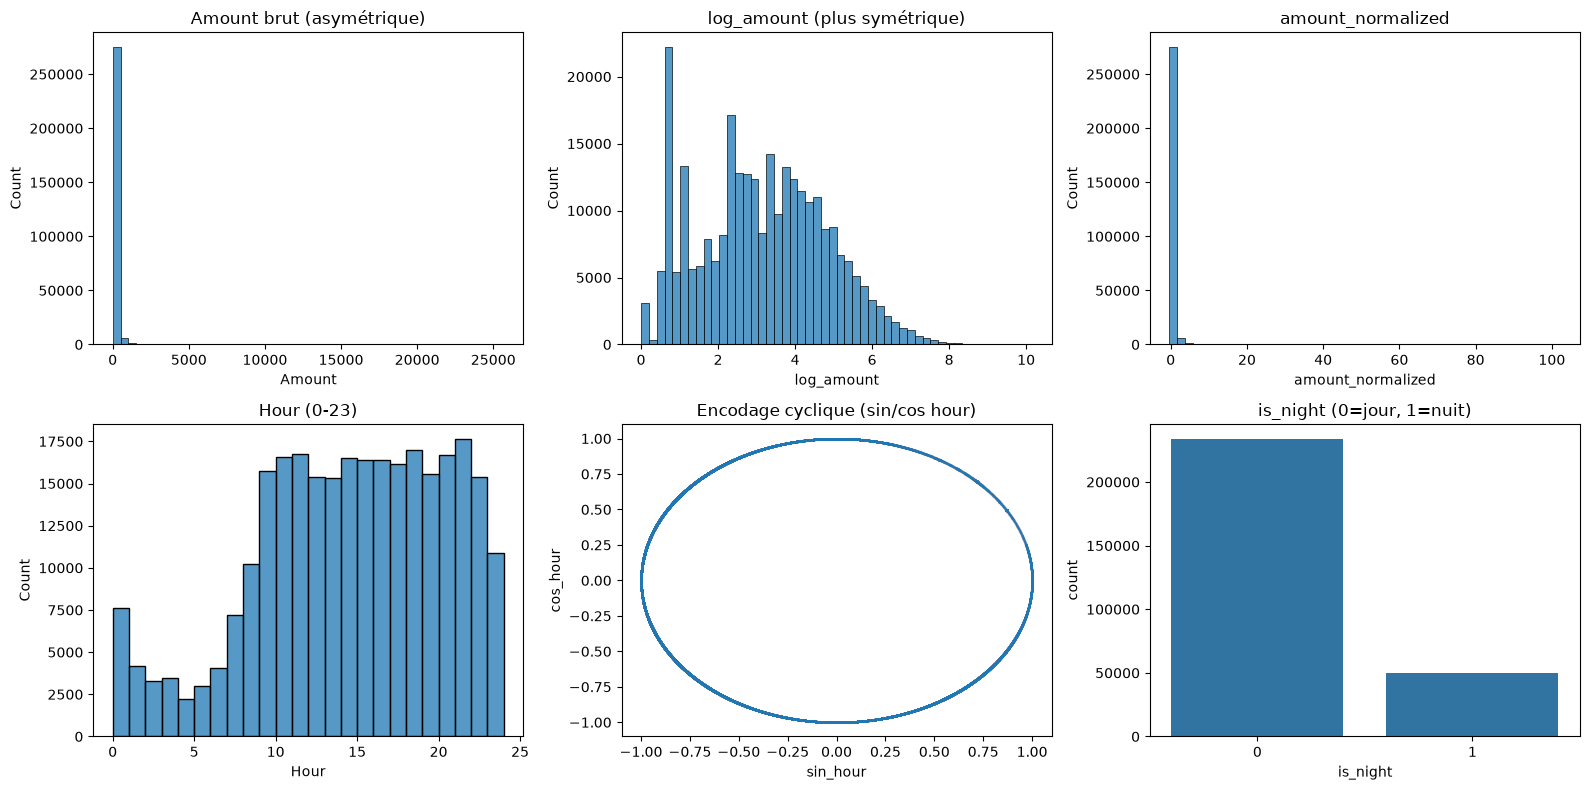

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Amount brut vs log_amount
sns.histplot(df['Amount'], ax=axes[0,0], bins=50)
axes[0,0].set_title('Amount brut (asymétrique)')

sns.histplot(df['log_amount'], ax=axes[0,1], bins=50)
axes[0,1].set_title('log_amount (plus symétrique)')

sns.histplot(df['amount_normalized'], ax=axes[0,2], bins=50)
axes[0,2].set_title('amount_normalized')

# Features temporelles
sns.histplot(df['Hour'], ax=axes[1,0], bins=24)
axes[1,0].set_title('Hour (0-23)')

axes[1,1].scatter(df['sin_hour'], df['cos_hour'], alpha=0.01, s=1)
axes[1,1].set_title('Encodage cyclique (sin/cos hour)')
axes[1,1].set_xlabel('sin_hour')
axes[1,1].set_ylabel('cos_hour')

sns.countplot(data=df, x='is_night', ax=axes[1,2])
axes[1,2].set_title('is_night (0=jour, 1=nuit)')

plt.tight_layout()
plt.show()

In [5]:
# Sauvegarde du dataset avec features engineered
df.to_csv('../data/creditcard_features.csv', index=False)
print(f"Dataset enrichi sauvegardé : {df.shape}")
print(f"\nNouvelles features créées :")
new_features = ['Hour', 'sin_hour', 'cos_hour', 'is_night', 
                'log_amount', 'amount_normalized', 'amount_x_night']
for f in new_features:
    print(f"  ✓ {f}")

Dataset enrichi sauvegardé : (283726, 37)

Nouvelles features créées :
  ✓ Hour
  ✓ sin_hour
  ✓ cos_hour
  ✓ is_night
  ✓ log_amount
  ✓ amount_normalized
  ✓ amount_x_night
